# How to extract a SatCLIP feature:

In [ ]:
# Ensure Hugging Face and Torch caches are set before imports
import os
cwd = os.getcwd()

cache_dir = "/home/sazhang/.cache"
hf_cache = f"{cache_dir}/huggingface"
torch_cache = f"{cache_dir}/torch"

os.environ["HF_HOME"] = hf_cache
os.environ["HF_HUB_CACHE"] = f"{hf_cache}/hub"
os.environ["TRANSFORMERS_CACHE"] = f"{hf_cache}/transformers"
os.environ["TORCH_HOME"] = torch_cache

# If huggingface_hub was imported earlier in this kernel, reload constants
import importlib
import huggingface_hub.constants as hf_const
importlib.reload(hf_const)
print("HF_HOME:", hf_const.HF_HOME)
print("HF_HUB_CACHE:", hf_const.HF_HUB_CACHE)
print("TORCH_HOME:", os.environ["TORCH_HOME"])

HF_HOME: /home/sazhang/.cache/huggingface
HF_HUB_CACHE: /home/sazhang/.cache/huggingface/hub
TORCH_HOME: /home/sazhang/.cache/torch


In [4]:
import sys
sys.path.append(f'{cwd}/satclip/satclip') # add satclip module from satclip repo to path

# Explicitly set via pyproj API
conda_env_path = "/home/sazhang/miniconda3/envs/downscaling"
proj_path = f"{conda_env_path}/share/proj"

os.environ["PROJ_LIB"] = proj_path
os.environ["PROJ_DATA"] = proj_path

import pyproj
pyproj.datadir.set_data_dir(proj_path)

/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


Pretrained SatCLIP models are hosted on Hugging Face, where we can easily access them. Here, for example, we use the $L=40$ version with a ResNet18 backbone.

In [5]:
from huggingface_hub import hf_hub_download
from load import get_satclip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ResNet18-L40", "satclip-resnet18-l40.ckpt", cache_dir=cache_dir),
    device=device,
)  # Only loads location encoder by default

mkdir -p failed for path /afs/csail.mit.edu/u/s/sazhang/.config/matplotlib: [Errno 13] Permission denied: '/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-1b_eycnt because there was an issue with the default path (/afs/csail.mit.edu/u/s/sazhang/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


using pretrained moco resnet18


In [6]:
c = torch.randn(1, 2)  # Represents a batch of 32 locations (lon/lat)

model.eval()
with torch.no_grad():
    emb = model(c.double().to(device)).detach().cpu()
emb

tensor([[ 2.3843,  2.4956, -0.2198, -2.2482,  1.5193, -1.8001,  3.6891, -0.6677,
          2.0425, -0.8528, -0.4831, -0.8424, -3.1003,  0.0207, -1.5719,  0.8866,
         -0.0909,  1.0288,  1.1095,  0.1947, -3.2920, -0.0693, -2.0865,  0.3143,
         -2.5232, -0.6281,  1.9297,  0.3003,  0.2586, -2.8945,  1.2127,  1.2198,
         -1.4930,  1.6990, -0.1714, -2.1612,  1.0627, -1.0370, -0.0761,  2.2149,
         -0.3090, -3.0080, -1.8250, -1.1363,  1.9321, -1.0138,  0.8854, -1.2441,
          1.3935,  0.8604,  0.7683, -1.2623,  2.2585, -0.1980, -0.8318, -1.7178,
         -1.1631, -0.4175,  1.3108, -3.7585, -4.3381,  0.9277,  0.1785, -1.1643,
         -2.2434,  2.6287, -1.4442, -3.8339, -0.4688,  0.2174,  1.8605,  0.3575,
          1.1811,  0.9049, -1.6130,  1.3498, -1.9082,  1.4012,  4.4197, -1.3793,
         -0.3002, -0.3247, -4.2796, -2.6128, -2.3436,  1.5045, -0.6953, -2.4777,
          3.8034,  2.5704,  1.9438, -1.9547,  2.5121,  1.1376, -2.3612,  0.4294,
         -2.5258, -0.9602, -

# PCA Visualization of embeddings
Sample all lat (degrees north) [-90, 90] lon (degrees east) [-180, 180] at 1 degree resolution (make it higher later)
Filter to land mass only (optional) and plot it over a map

In [ ]:

import numpy as np
# import random_land_points as rlp  # https://github.com/duncaneddy/random-land-points/tree/main
from global_land_mask import globe  # treats lakes as on-land

x = np.linspace(-180, 180, 361)  # 1 degree resolution
y = np.linspace(-90, 90, 181)
lon_grid, lat_grid = np.meshgrid(x, y)
coords = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=-1)  # shape: (N, 2)

land_mask = globe.is_land(coords[:, 1], coords[:, 0])  # lat, lon order
land_coords = coords[land_mask]
land_coords.shape

(21677, 2)

Text(0.5, 1.0, 'Gridded Land Points')

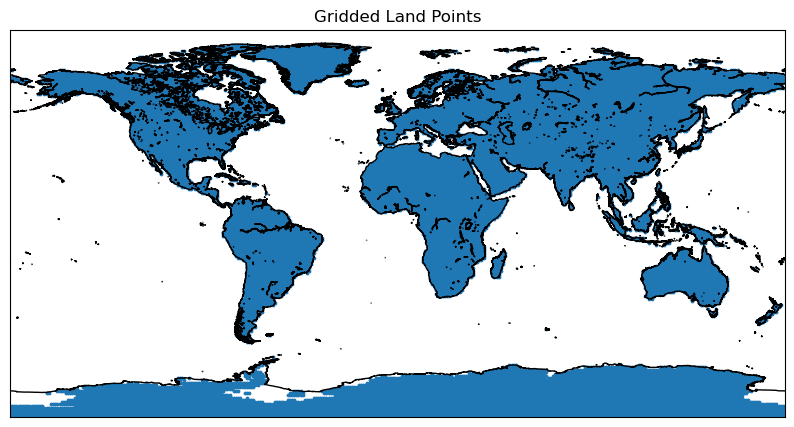

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset

fig, ax = plt.subplots(1, figsize=(10, 6))

# resolution: 'c' for crude, 'l' for low, 'i' for intermediate ['h' for high, 'f' for full -- install separately]
m = Basemap(projection='cyl', resolution='i', ax=ax) # how do i know what projection to use???
m.drawcoastlines()
ax.scatter(land_coords[:,0], land_coords[:,1], s=3)
ax.set_title('Gridded Land Points')

In [ ]:

batch_size = 256

# Prepare data and batching (using land_coords from previous cell)
c_tensor = torch.tensor(land_coords, dtype=torch.float64) # The model expects doubles
dataset = TensorDataset(c_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# Get embeddings in batches
model.eval()
all_embs = []
with torch.no_grad():
    for batch in dataloader:
        # Move batch to device (batch[0] contains the coordinates)
        emb = model(batch[0].to(device))
        all_embs.append(emb.cpu().numpy())

# Shape: (5453, embedding_dim)
embeddings = np.concatenate(all_embs, axis=0) 

# Run PCA to extract the top 3 components
pca = PCA(n_components=3)
pca_embs = pca.fit_transform(embeddings)


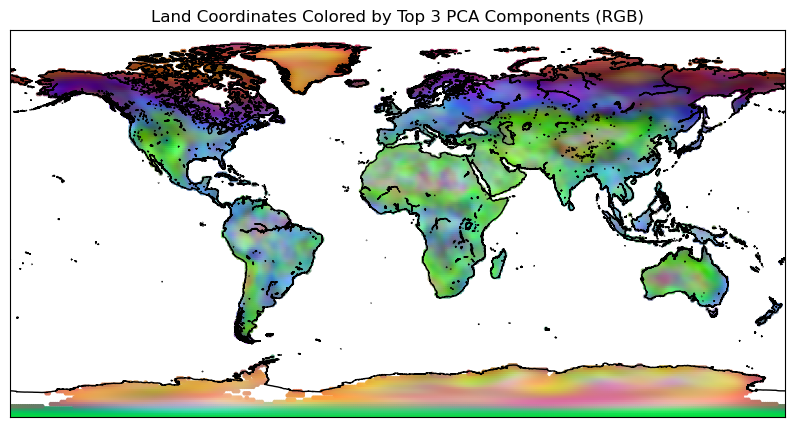

In [ ]:
# Normalize the 3 PCA components to [0, 1] for RGB colors
colors = pca_embs - pca_embs.min(axis=0, keepdims=True)
colors = colors / (colors.max(axis=0, keepdims=True) + 1e-8)

# Plot over a map
fig, ax = plt.subplots(1, figsize=(10, 6))

m = Basemap(projection='cyl', resolution='i', ax=ax)
m.drawcoastlines()

# Scatter using the coordinates and the PCA RGB colors
ax.scatter(land_coords[:, 0], land_coords[:, 1], c=colors, s=5)
ax.set_title('Land Coordinates Colored by Top 3 PCA Components of ')

plt.show()

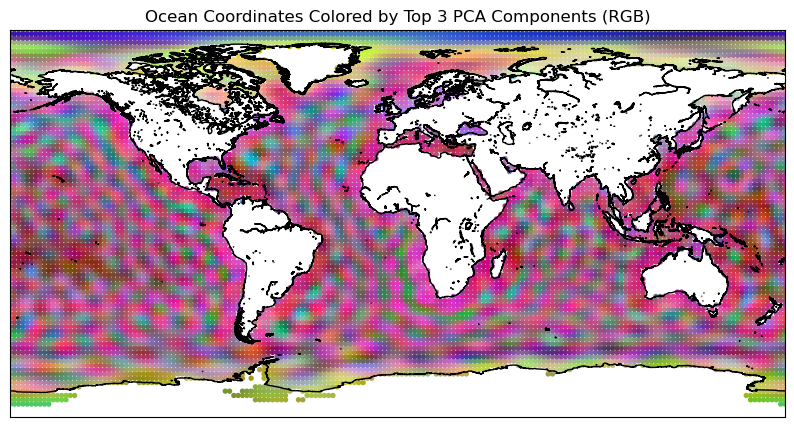

In [ ]:
x = np.linspace(-180, 180, 181)  # 1 degree resolution
y = np.linspace(-90, 90, 91)
lon_grid, lat_grid = np.meshgrid(x, y)
coords = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=-1)  # shape: (N, 2)

land_mask = globe.is_land(coords[:, 1], coords[:, 0])  # lat, lon order
ocean_coords = coords[~land_mask]


batch_size = 256
c_tensor = torch.tensor(ocean_coords, dtype=torch.float64) # The model expects doubles
dataset = TensorDataset(c_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# Get embeddings in batches
model.eval()
all_embs = []
with torch.no_grad():
    for batch in dataloader:
        # Move batch to device (batch[0] contains the coordinates)
        emb = model(batch[0].to(device))
        all_embs.append(emb.cpu().numpy())

# Shape: (5453, embedding_dim)
embeddings = np.concatenate(all_embs, axis=0) 

# Run PCA to extract the top 3 components
pca = PCA(n_components=3)
pca_embs = pca.fit_transform(embeddings)

# Normalize the 3 PCA components to [0, 1] for RGB colors
colors = pca_embs - pca_embs.min(axis=0, keepdims=True)
colors = colors / (colors.max(axis=0, keepdims=True) + 1e-8)

# Plot over a map
fig, ax = plt.subplots(1, figsize=(10, 6))

m = Basemap(projection='cyl', resolution='i', ax=ax)
m.drawcoastlines()

# Scatter using the coordinates and the PCA RGB colors
ax.scatter(ocean_coords[:, 0], ocean_coords[:, 1], c=colors, s=8)
ax.set_title('Ocean Coordinates Colored by Top 3 PCA Components (RGB)')

plt.show()


interesting pattern here. curious if it means anything? given the model was only actually trained on landmass imagery

# Dim Reduction of Regions: tSNE and UMAP

In [ ]:
import pandas as pd

rainshift_df = pd.read_csv("./outputs/rainshift_regions_info.csv")

resolution = 0.5
regions_coords = {}
for idx, row in rainshift_df.iterrows():
    region, lat_min, lat_max, lon_min, lon_max = row['region'], row['lat_min'], row['lat_max'], row['lon_min'], row['lon_max']
    x = np.linspace(lon_min, lon_max, int((lon_max - lon_min) / resolution) + 1)  # 1 degree resolution
    y = np.linspace(lat_min, lat_max, int((lat_max - lat_min) / resolution) + 1)
    lon_grid, lat_grid = np.meshgrid(x, y)
    coords = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=-1)  # shape: (N, 2)

    regions_coords[region] = coords

In [ ]:

regions_embeddings = {}
for region, coords in regions_coords.items():
    print("Encoding region", region)
    c_tensor = torch.tensor(coords, dtype=torch.float64) # The model expects doubles
    dataset = TensorDataset(c_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    # Get embeddings in batches
    model.eval()
    all_embs = []
    with torch.no_grad():
        for batch in dataloader:
            # Move batch to device (batch[0] contains the coordinates)
            emb = model(batch[0].to(device))
            all_embs.append(emb.cpu().numpy())

    # Shape: (N, embedding_dim)
    embeddings = np.concatenate(all_embs, axis=0) 
    regions_embeddings[region] = embeddings



Encoding region africa-south
Encoding region amazon-basin
Encoding region arabian-peninsula
Encoding region australasia-east
Encoding region blacksea
Encoding region cape-horn
Encoding region caribbean
Encoding region east-asia-north-east
Encoding region east-asia-south
Encoding region europe_west
Encoding region horn-of-africa
Encoding region melanesia
Encoding region northamerica-east
Encoding region northamerica-west
Encoding region southamerica-east
Encoding region southeastasia-west
Encoding region tibetan-plateau
Encoding region west-africa


In [ ]:
import os
import numpy as np

save_dir = "rainshift_satclip_features"
os.makedirs(save_dir, exist_ok=True)

# Save to .npz files
for region in regions_coords.keys():
    coords_file = os.path.join(save_dir, f"{region}_coords.npz")
    emb_file = os.path.join(save_dir, f"{region}_embeddings_satclip.npz")
    
    np.savez(coords_file, data=regions_coords[region])
    np.savez(emb_file, data=regions_embeddings[region])
    
print(f"Saved coordinates and embeddings to ./{save_dir}/")

Saved coordinates and embeddings to ./rainshift_satclip_features/


In [ ]:
# Load from .npz files
loaded_regions_coords = {}
loaded_regions_embeddings = {}

for region in rainshift_df['region']:
    coords_file = os.path.join(save_dir, f"{region}_coords.npz")
    emb_file = os.path.join(save_dir, f"{region}_embeddings_satclip.npz")
    
    if os.path.exists(coords_file) and os.path.exists(emb_file):
        loaded_regions_coords[region] = np.load(coords_file)['data']
        loaded_regions_embeddings[region] = np.load(emb_file)['data']

print("Successfully loaded regions:", list(loaded_regions_coords.keys()))

Computing t-SNE...
Computing UMAP...


/home/sazhang/miniconda3/envs/downscaling/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


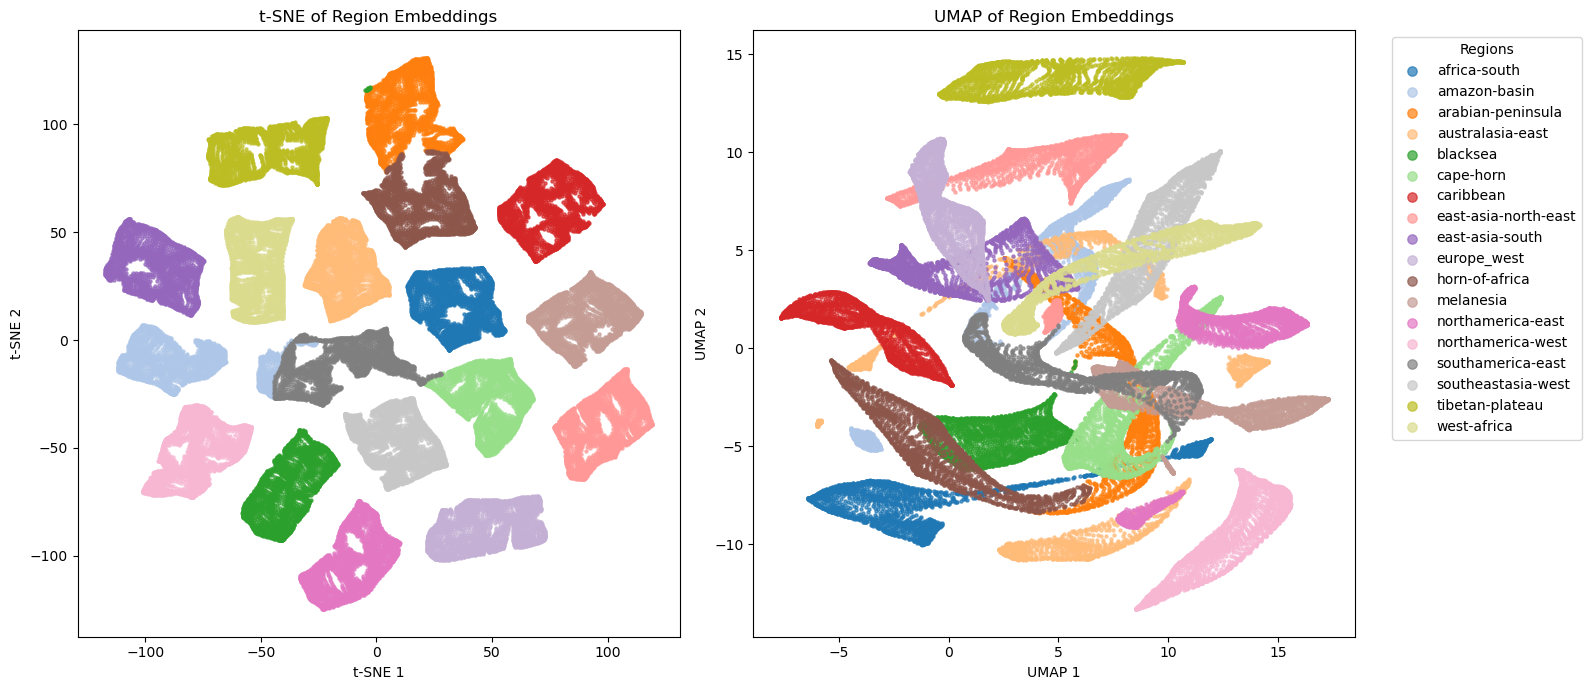

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap 

# Combine all embeddings and track their corresponding region labels
all_embs_list = []
labels_list = []

for region, embs in loaded_regions_embeddings.items():
    all_embs_list.append(embs)
    labels_list.extend([region] * len(embs))

combined_embeddings = np.concatenate(all_embs_list, axis=0)
labels_array = np.array(labels_list)
unique_regions = list(loaded_regions_embeddings.keys())

# Compute t-SNE (2 dimensions)
print("Computing t-SNE...")
tsne = TSNE(n_components=2, random_state=42)
tsne_embs = tsne.fit_transform(combined_embeddings)

# Compute UMAP (2 dimensions)
print("Computing UMAP...")
reducer = umap.UMAP(n_components=2, random_state=42)
umap_embs = reducer.fit_transform(combined_embeddings)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
cmap = plt.get_cmap("tab20")  # Good for up to 20 distinct classes

for i, region in enumerate(unique_regions):
    idx = labels_array == region
    color = cmap(i % 20)
    
    # Scatter for t-SNE
    axes[0].scatter(tsne_embs[idx, 0], tsne_embs[idx, 1], s=5, c=[color], label=region, alpha=0.7)
    # Scatter for UMAP
    axes[1].scatter(umap_embs[idx, 0], umap_embs[idx, 1], s=5, c=[color], label=region, alpha=0.7)

axes[0].set_title('t-SNE of Region Embeddings')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

axes[1].set_title('UMAP of Region Embeddings')
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# Add legend outside the plots
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, title="Regions")

plt.tight_layout()
plt.savefig("outputs/satclip_embeddings_by_region_tsne_umap.png", dpi=300, bbox_inches="tight")
plt.show()

also save plots separately:

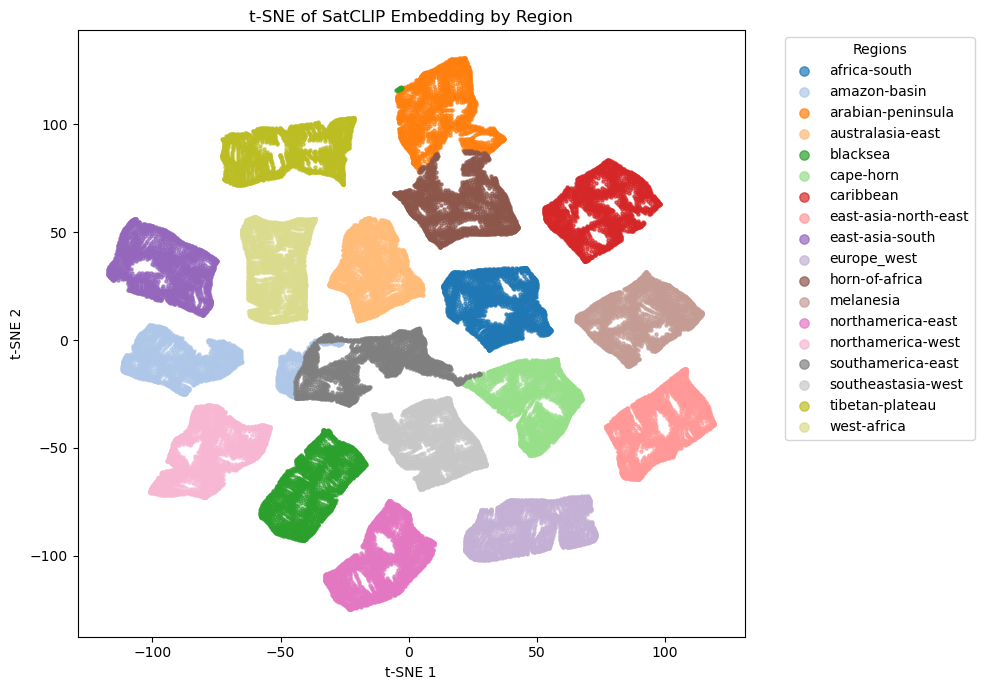

In [ ]:
# save umap and tsne plots separately
fig, ax = plt.subplots(1, figsize=(10, 7))
cmap = plt.get_cmap("tab20")  # Good for up to 20 distinct classes

for i, region in enumerate(unique_regions):
    idx = labels_array == region
    color = cmap(i % 20)
    
    # Scatter for t-SNE
    ax.scatter(tsne_embs[idx, 0], tsne_embs[idx, 1], s=5, c=[color], label=region, alpha=0.7)

ax.set_title('t-SNE of SatCLIP Embedding by Region')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')


# Add legend outside the plots
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, title="Regions")

plt.tight_layout()
plt.savefig("outputs/satclip_embeddings_by_region_tsne.png", dpi=300, bbox_inches="tight")
plt.show()



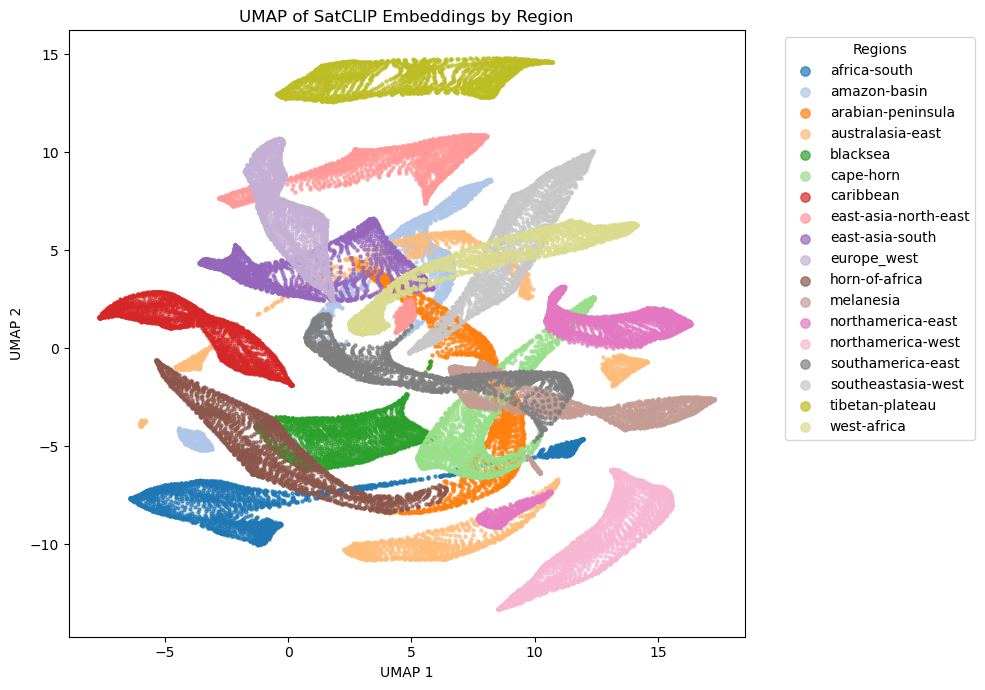

In [ ]:
# save umap and tsne plots separately
fig, ax = plt.subplots(1, figsize=(10, 7))
cmap = plt.get_cmap("tab20")  # Good for up to 20 distinct classes

for i, region in enumerate(unique_regions):
    idx = labels_array == region
    color = cmap(i % 20)
    
    # Scatter for UMAP
    ax.scatter(umap_embs[idx, 0], umap_embs[idx, 1], s=5, c=[color], label=region, alpha=0.7)

ax.set_title('UMAP of SatCLIP Embeddings by Region')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

# Add legend outside the plots
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=3, title="Regions")

plt.tight_layout()
plt.savefig("outputs/satclip_embeddings_by_region_umap.png", dpi=300, bbox_inches="tight")
plt.show()